# Исследование стартапов

## Введение

Цель: провести исследование динамики и структуры финансирования стартапов, ответить на вопросы, важные для оценки инвестиционных стратегий.

Задачи: ознакомление с данными,
подготовка датасета к работе, инжиниринг признаков, работа с выбросами и анализ, анализ дианмики, итоговый вывод и рекомендации.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.
### 1.1. Вывод общей информации


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df1 = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [3]:
df2 = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [5]:
df1.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df1.isna().sum()

name                     4857
homepage_url             8305
category_list            8817
 market                  8817
 funding_total_usd       4856
status                   6170
country_code            10129
state_code              24133
region                  10129
city                    10972
funding_rounds           4856
participants            23821
founded_at              15740
founded_month           15812
founded_quarter         15812
founded_year            15740
first_funding_at         4856
mid_funding_at          24006
last_funding_at          4856
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_A                  4856
round_B   

In [7]:
df1.isna().sum() / df1.shape[0]

name                    0.089457
homepage_url            0.152963
category_list           0.162394
 market                 0.162394
 funding_total_usd      0.089439
status                  0.113641
country_code            0.186558
state_code              0.444487
region                  0.186558
city                    0.202085
funding_rounds          0.089439
participants            0.438741
founded_at              0.289903
founded_month           0.291229
founded_quarter         0.291229
founded_year            0.289903
first_funding_at        0.089439
mid_funding_at          0.442148
last_funding_at         0.089439
seed                    0.089439
venture                 0.089439
equity_crowdfunding     0.089439
undisclosed             0.089439
convertible_note        0.089439
debt_financing          0.089439
angel                   0.089439
grant                   0.089439
private_equity          0.089439
post_ipo_equity         0.089439
post_ipo_debt           0.089439
secondary_

In [8]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [9]:
df2.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [10]:
df2.isna().sum()

year                    0
seed                    0
venture                 0
equity_crowdfunding     0
undisclosed             0
convertible_note        0
debt_financing          0
angel                   0
grant                   0
private_equity          0
post_ipo_equity         0
post_ipo_debt           0
secondary_market        0
product_crowdfunding    0
dtype: int64

In [11]:
# понадобится позже: исходная длина первого датасета
temp = df1.copy() 
len(temp)

54294

Были загружены датасеты cb_investments (df1) и cb_returns (df2). 

- df1: 54294 строк и 40 столбцов
- df2: 15 строк и 14 столбцов

Данные соответствуют описанию. В датасете df1 стоит поправить названия столбцов (привести в нижнему регистру, удалить лишние пробелы). В обоих датасетах можно оптимизировать типы данных. В датасете df1 есть пропущенные значения в каждом из столбцов, в df2 нет пропусков.

### 1.2. Предобработка данных

In [12]:
# приведем к нижнему регистру и избавимся от лишних пропусков
df1.columns = df1.columns.str.lower().str.strip() 
df1.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='object')

In [13]:
df2.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

Уберем в столбце `funding_total_usd` выделение разрядов и приведем его к числовому типу.

In [14]:
df1['funding_total_usd'] = df1['funding_total_usd'].str.strip().str.replace(',', '')

In [15]:
df1['funding_total_usd'] = pd.to_numeric(df1['funding_total_usd'],errors='coerce')

Обработаем типы данных в столбцах, которые хранят значения даты и времени.

In [16]:
df1['first_funding_at'] = pd.to_datetime(df1['first_funding_at'],errors='coerce')
df1['last_funding_at'] = pd.to_datetime(df1['last_funding_at'],errors='coerce')

In [17]:
df1['mid_funding_at'] = pd.to_datetime(df1['mid_funding_at'],errors='coerce')

In [18]:
df2['year'] = pd.to_numeric(df2['year'], downcast='integer')
df2['year'].dtype

dtype('int16')

In [19]:
df1['founded_at'] = pd.to_datetime(df1['founded_at'], errors='coerce')

In [20]:
df1['founded_year'] = pd.to_numeric(df1['founded_year'], errors='coerce')

In [21]:
# понижаем разрядность числовых данных
float_cols = df1.select_dtypes(include=['float']).columns
for col in float_cols:
    df1[col] = pd.to_numeric(df1[col], downcast='float')

In [22]:
# понижаем разрядность числовых данных
float_cols2 = df2.select_dtypes(include=['float']).columns
for col in float_cols2:
    df2[col] = pd.to_numeric(df2[col], downcast='float')

В датасете `cb_returns` сделаем столбец `year` индексом всего датасета

In [23]:
df2 = df2.set_index('year')

Обработаем текстовые данные. Пропуски в текстовых столбцах заполним заглушками там, где это понадобится.

In [ ]:
text_columns = df1.select_dtypes(include=['object']).columns
text_columns

Index(['name', 'homepage_url', 'category_list', 'market', 'status',
       'country_code', 'state_code', 'region', 'city', 'founded_month',
       'founded_quarter'],
      dtype='object')

нормализация

In [ ]:
for col in text_columns:
    df1[col] = df1[col].astype(str).str.strip().str.lower()

проверка заглушки на уникальность

In [ ]:
for col in text_columns:
    print(df1[col].str.contains('not_defined').sum())

0
0
0
0
0
0
0
0
0
0
0


Заполняем пропуски заглушкой "not_defined"

In [ ]:
df1[text_columns] = df1[text_columns].fillna('not_defined')

Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`. 

явные дубликаты:

In [ ]:
df1.duplicated().sum()

4855

In [ ]:
df2.duplicated().sum()

0

удаляем их

In [ ]:
df1 = df1.drop_duplicates()

In [31]:
df1.shape

(49439, 40)

Удалим пропуски в funding_total_usd:

In [32]:
df1 = df1.dropna(subset=['funding_total_usd'])

In [33]:
df1['funding_total_usd'].isna().sum()

0

Убрали строки, не содержащие данные о финансировании

Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами.

Оценим размер оставшихся пропусков в столбце.

In [ ]:
mid_dates = df1['first_funding_at'] + (df1['last_funding_at'] - df1['first_funding_at']) / 2

df1['mid_funding_at'] = df1['mid_funding_at'].fillna(mid_dates)

In [35]:
df1['mid_funding_at'].isna().sum()

1

Пропусков в этом столбце не осталось

Оценим полноту данных, сделаем предварительный вывод о том, достаточно ли данных для решения задач проекта.

In [36]:
a, b = len(temp), len(df1)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2),
      '\n', "Процент оставшихся данных", round(b/a*100, 2))

 Было строк в исходном датасете 54294 
 Осталось строк в датасете после обработки 40907 
 Удалено строк в датасете после обработки 13387 
 Процент потерь 24.66 
 Процент оставшихся данных 75.34


На этом предобработка завершена.

В результате предобработки данных были выполнены следующие действия:
- приведение названий столбцов к единому стилю (df1)
- приведение funding_total_usd к числовому типу после обработки строк
- обработка типов даты
- оптимизация численных типов
- year был сделан индексом второго датасета
- нормализация текстовых данных
- заполнение пропусков в текстовых данных уникальной заглушеой not_defined
- удаление полных дубликатов
- исследование funding_total_usd на пропуски
- заполнение mid_funding_at 
- на основании значений в столбцах first_funding_at и last_funding_at

В процессе предобработки длина датасета df1 уменьшилась на 13387 строк (24.66%). Удалили дубликаты и строки, не несущие данные о финансировании. Из 54294 строк осталось 40907 (75.34%). Объем данных достаточен для предстоящего анализа.
Размер датасета df2 остался исходным.

In [37]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40907 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40907 non-null  object        
 1   homepage_url          40907 non-null  object        
 2   category_list         40907 non-null  object        
 3   market                40907 non-null  object        
 4   funding_total_usd     40907 non-null  float32       
 5   status                40907 non-null  object        
 6   country_code          40907 non-null  object        
 7   state_code            40907 non-null  object        
 8   region                40907 non-null  object        
 9   city                  40907 non-null  object        
 10  funding_rounds        40907 non-null  float32       
 11  participants          27331 non-null  float32       
 12  founded_at            32200 non-null  datetime64[ns]
 13  founded_month   

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: какой процент от общего числа компаний относится к каждой из трёх групп?
* По объёму инвестиций: какую долю от общего объёма привлечённых средств получила каждая группа?

In [38]:
def categorize(row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    duration_days = (row['last_funding_at'] - row['first_funding_at']).days
    if duration_days <= 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

df1['funding_group'] = df1.apply(categorize, axis=1)


In [39]:
table_cat = (
    df1
    .groupby('funding_group')
    .agg({'funding_group': 'count'})
    .rename(columns={'funding_group': 'count'})
    .sort_values(by='count', ascending=False)
    .reset_index()
)

table_cat['share'] = table_cat['count'] / table_cat['count'].sum() * 100
table_cat

,funding_group,count,share
0,Единичное финансирование,24113,58.945902
1,Срок финансирования более года,12293,30.051092
2,Срок финансирования до года,4501,11.003007


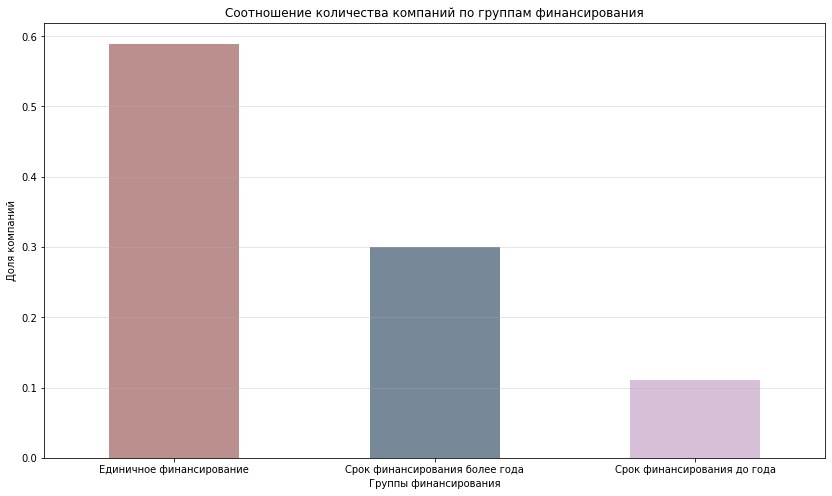

In [40]:
plt.figure(figsize=(14, 8))

colors = ['rosybrown', 'lightslategrey', 'thistle'] 
df1['funding_group'].value_counts(normalize=True).plot(
               kind='bar', 
               rot=0, 
               legend=False,
               color=colors,
               title=f'Cоотношение количества компаний по группам финансирования'
)

plt.xlabel('Группы финансирования')
plt.ylabel('Доля компаний')
plt.grid(axis='y', alpha=0.4)
plt.show()

In [41]:
table_cat = (
    df1
    .groupby('funding_group')
    .agg({'funding_total_usd': 'sum'})
    .rename(columns={'funding_total_usd': 'sum'})
    .reset_index()
)
table_cat['share'] = table_cat['sum'] / table_cat['sum'].sum() * 100
table_cat

,funding_group,sum,share
0,Единичное финансирование,1.993044e+11,30.618238
1,Срок финансирования более года,4.027433e+11,61.871632
2,Срок финансирования до года,4.888598e+10,7.510132


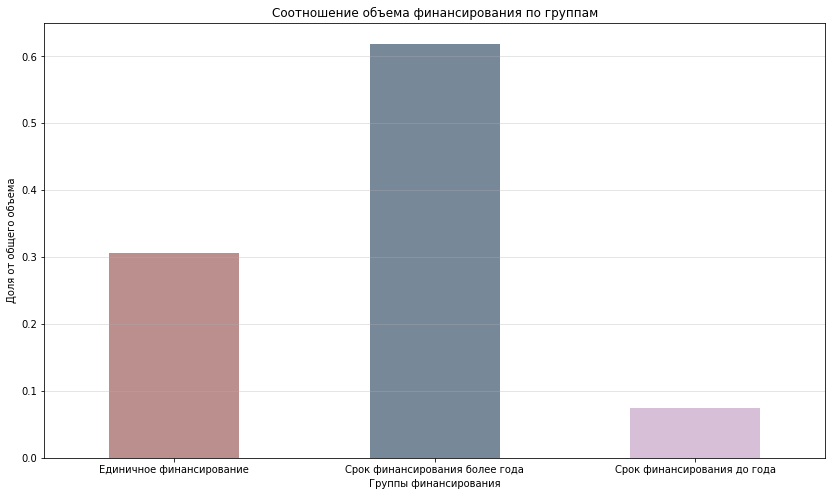

In [42]:
plt.figure(figsize=(14, 8))

colors = ['rosybrown', 'lightslategrey', 'thistle']

funding_data = df1.groupby('funding_group')['funding_total_usd'].sum()
funding_percent = (funding_data / funding_data.sum())

funding_percent.plot(
               kind='bar', 
               rot=0, 
               legend=False,
               color=colors,
               title='Соотношение объема финансирования по группам'
)

plt.xlabel('Группы финансирования')
plt.ylabel('Доля от общего объема')
plt.grid(axis='y', alpha=0.4)
plt.show()


После разделения всех компаний на группы по раундам финансирования, можем видеть следующие результаты: компании с единичным финансированием составляют почти 59% от количества компаний. На втором месте по количеству - компании со сроком финансирования более года - 30%. Всего 11% - компании с финансированием менее года. Такое распределение можно объяснить низкой выживаемостью старт-апов.

Рассматривая суммы финансирования, видим следующую картину: более 60% капитала уходит на "проверенные" компании (более года), единичное финансирование - 30% (финансируется большОе количество проектов), всего 7.5% - до года.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно - к средним, а сегменты до 35 компаний - к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

Построим график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты.

In [43]:
segment_counts = df1['market'].value_counts()
df1['companies_in_segment'] = df1['market'].map(segment_counts)

def categorize_market_type(row):
    count = row['companies_in_segment']
    if count > 120:
        return 'Массовые'
    elif 35 <= count <= 120:
        return 'Средние'
    else:
        return 'Нишевые'

df1['market_category'] = df1.apply(categorize_market_type, axis=1)

unique_segments = df1.drop_duplicates('market')
unique_segments['market_category'].value_counts()

Нишевые     289
Средние      57
Массовые     49
Name: market_category, dtype: int64

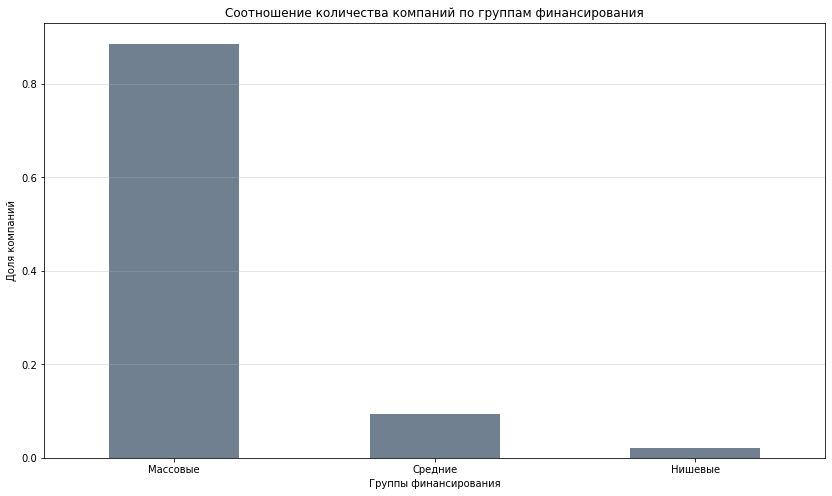

In [44]:
plt.figure(figsize=(14, 8))

colors = ['slategray'] 
df1['market_category'].value_counts(normalize=True).plot(
               kind='bar', 
               rot=0, 
               legend=False,
               color=colors,
               title=f'Cоотношение количества компаний по группам финансирования'
)

plt.xlabel('Группы финансирования')
plt.ylabel('Доля компаний')
plt.grid(axis='y', alpha=0.4)
plt.show()

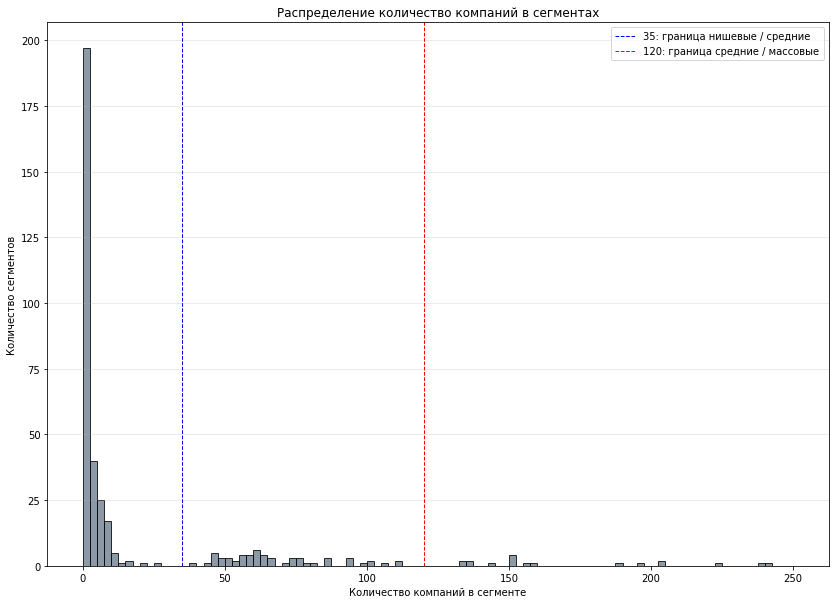

In [45]:
plt.figure(figsize=(14, 10))

plt.hist(unique_segments['companies_in_segment'], 
         bins=100,
         range=(0, 250),       
         color='slategray', 
         edgecolor='black', 
         alpha=0.8,
        )

plt.axvline(35, color='blue', linestyle='--', linewidth=1, label='35: граница нишевые / средние')
plt.axvline(120, color='red', linestyle='--', linewidth=1, label='120: граница средние / массовые')

plt.title('Распределение количество компаний в сегментах')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()


Большое количество нишевых и средних сегментов рынка, поэтому далее их сгруппируем в категории


Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.


In [46]:
df1.loc[df1['market_category'] == 'Нишевые', 'market'] = 'niche'
df1.loc[df1['market_category'] == 'Средние', 'market'] = 'mid'
# все сегменты после заглушек
df1['market'].value_counts()

software                4812
mid                     3841
biotechnology           3590
nan                     2503
mobile                  2344
e-commerce              1866
curated web             1693
enterprise software     1381
health care             1185
clean technology        1180
games                   1117
advertising             1107
hardware + software     1062
social media            1003
health and wellness      873
education                844
niche                    830
finance                  828
analytics                667
manufacturing            596
security                 567
semiconductors           484
web hosting              424
consulting               349
hospitality              336
travel                   330
fashion                  303
news                     301
messaging                295
search                   291
real estate              279
saas                     272
music                    264
internet                 241
technology    

Можем рассмотреть новый список сегментов после замены. Самый популярный сегмент рынка - software, на втором месте по количеству - средний сегмент (наша новая группа), на третьем - biotechnology.
Основная часть компаний сконцентрирована в одном массовом сегменте, существенная доля приходится на нишевые рынки. Такой разброс указывает на высокую диверсификацию стартап-рынка, что важно учитывать при оценке инвестиционной привлекательности различных отраслей

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По столбцу `funding_total_usd` оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Найдем интервал, в котором лежат типичные значения.

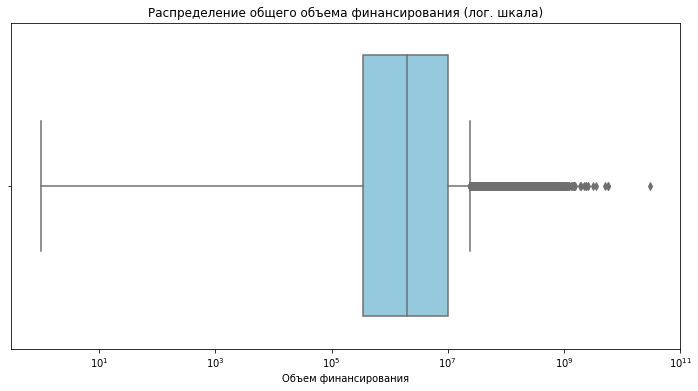

In [47]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df1['funding_total_usd'], color='skyblue')
plt.xscale('log') 
plt.title('Распределение общего объема финансирования (лог. шкала)')
plt.xlabel('Объем финансирования')
plt.show()


In [48]:
df1['funding_total_usd'].describe()

count    4.090700e+04
mean     1.591252e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

In [49]:
stats = df1['funding_total_usd'].describe()

q1 = stats['25%']
q3 = stats['75%']
IQR = q3 - q1

lower_bound = max(df1['funding_total_usd'].min(), q1 - 1.5 * IQR)
upper_bound = q3 + 1.5 * IQR

q1, q3

(350000.0, 10000000.0)

In [50]:
upper_bound

24475000.0

Итак, получили типичный интервал от 350,000 до 10,000,000 USD. Данные, больше 24,475,000 USD, считаем выбросами.

Определим компании с аномальным объёмом общего финансирования — используем метод IQR отдельно по каждому сегменту.
Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.

In [51]:
# метод IQR
def is_outlier(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    return group > upper_bound

df1['is_outlier'] = df1.groupby('market')['funding_total_usd'].transform(is_outlier)

In [52]:
segment_analysis = df1.groupby('market').agg(
    total_companies=('is_outlier', 'count'),
    outlier_companies=('is_outlier', 'sum')
)

segment_analysis['outlier_share'] = segment_analysis['outlier_companies'] / segment_analysis['total_companies']

# топ-10 сегментов по доле аномалий
top_outlier_segments = segment_analysis.sort_values(by='outlier_share', ascending=False).head(10)

top_outlier_segments[['total_companies', 'outlier_share']]


,total_companies,outlier_share
market,,
real estate,279,0.172043
entertainment,150,0.166667
consulting,349,0.166189
search,291,0.164948
cloud computing,152,0.164474
saas,272,0.161765
photography,204,0.161765
technology,238,0.159664
video,188,0.159574


Сегмент с наибольшей долей компаний, получивших аномальное финансирование - real estate с 17.2%. Один из факторов такого результата, должно быть, характер сегмента - недвижимость требует огромных вложений на старте. На втором месте - entertainment, топ-10 замыкает группа нишевых сегментов.

Компании с аномально большими инвестициями могут искусственно увеличивать значения суммарного финансирования и искажать выводы о реальном положении дел.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим полноту данных за 2014 год. Затем исключим из датасета компании, которые получили аномальное финансирование.

На основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

Рассмотрим полноту данных 2014 года на основе столбца финального раунда финансирования

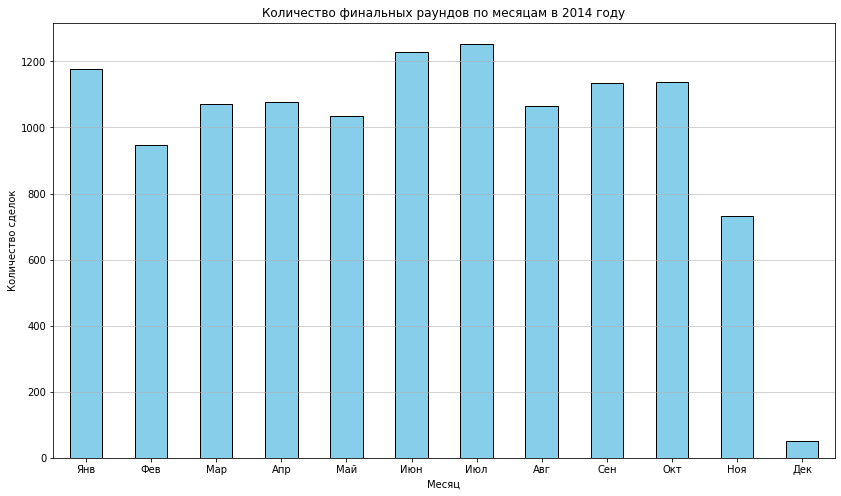

In [53]:
df_2014 = df1[df1['last_funding_at'].dt.year == 2014].copy()

df_2014['month'] = df_2014['last_funding_at'].dt.month

plt.figure(figsize=(14, 8))
df_2014['month'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Количество финальных раундов по месяцам в 2014 году')
plt.xlabel('Месяц')
plt.ylabel('Количество сделок')
plt.xticks(ticks=range(0, 12), labels=['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'], rotation=0)
plt.grid(axis='y', alpha=0.7)
plt.show()

In [54]:
df_2014['month'].value_counts().sort_index()

1     1178
2      947
3     1072
4     1077
5     1036
6     1229
7     1254
8     1064
9     1135
10    1139
11     732
12      52
Name: month, dtype: int64

In [ ]:
((df_2014['month'] == 12) & (df_2014['last_funding_at'].dt.day == 31)).any()

В декабре спад, но так как в датасете есть данные о финансировании за последний день года и о компаниях, основанных в последний месяц года, считаем, что данные за 2014 год полные.

Исключим из датасета компании, которые ранее посчитали получившими аномальное финансирование:

In [55]:
df_cleaned = df1[df1['is_outlier'] == False].copy()

len(df1) - len(df_cleaned)

5244

Удалили 5244 записей с аномальным финансированием

Оставим в датасете данные только о компаниях, получавших финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [56]:
df_cleaned['mid_funding_year'] = df_cleaned['mid_funding_at'].dt.year
df_cleaned['mid_funding_month'] = df_cleaned['mid_funding_at'].dt.month

rounds_per_year = df_cleaned.groupby('mid_funding_year')['funding_rounds'].count()

active_years = rounds_per_year[rounds_per_year >= 50].index

df_final = df_cleaned[df_cleaned['mid_funding_year'].isin(active_years)]

len(df_final)

35503

После фильтрации осталось 35503 компаний

### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег.

Также построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравним графики и выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [57]:
# Список всех типов финансирования
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant', 
    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
    'secondary_market', 'product_crowdfunding'
]

# сумма финансирования
total_amounts = df_final[funding_types].sum().sort_values(ascending=False)

# популярность
popularity = (df_final[funding_types] > 0).sum().sort_values(ascending=False)

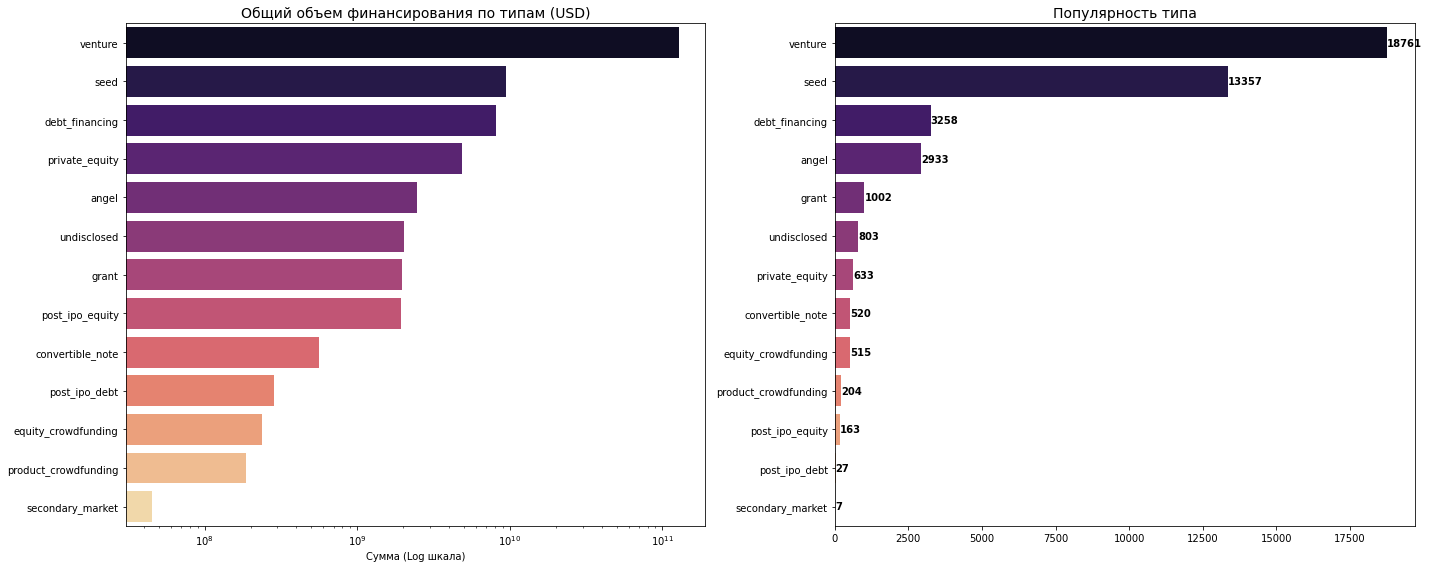

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# объем
sns.barplot(x=total_amounts.values, y=total_amounts.index, ax=axes[0], palette='magma')
axes[0].set_title('Общий объем финансирования по типам (USD)', fontsize=14)
axes[0].set_xscale('log')
axes[0].set_xlabel('Сумма (Log шкала)')

# популярность
sns.barplot(x=popularity.values, y=popularity.index, ax=axes[1], palette='magma')
axes[1].set_title('Популярность типа', fontsize=14)

for i, v in enumerate(popularity.values):
    axes[1].text(v + 3, i, str(int(v)), color='black', va='center', fontweight='bold')
    

plt.tight_layout()
plt.show()


Сравнив графики, можно заметить, что:

Venture - лидер по обоим показателям, одновременно и самый популярный (18 761), и у него самый большой объем капитала.

Есть часто используемые типы с небольшими объемами (категории, которые находятся высоко на графике популярности, но занимают более низкие или средние позиции по общему объему):
- Seed занимает второе место по популярности (13 357), но по объемам значительно уступает первому месту.
- Angel: Высокая популярность (встречаются 2 933 раза, четвертое место), но по суммарному объему находится лишь на пятом месте.

И также некоторые редкие типы со значительными объемами (категории, которые находятся низко в списке популярности, но находятся высоко в рейтинге общих сумм):
- Private Equity: редкие (всего встречаются 633 раза - седбмое место по популярности), но по объемам занимает четвертое место.
- Post-IPO Equity: тоже редкий, но по суммарному объему он сопоставим с грантами, которых в 6 раз больше.

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [59]:
return_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant', 
    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
    'secondary_market', 'product_crowdfunding'
]

total_returns = df2[return_types].sum().sort_values(ascending=False)

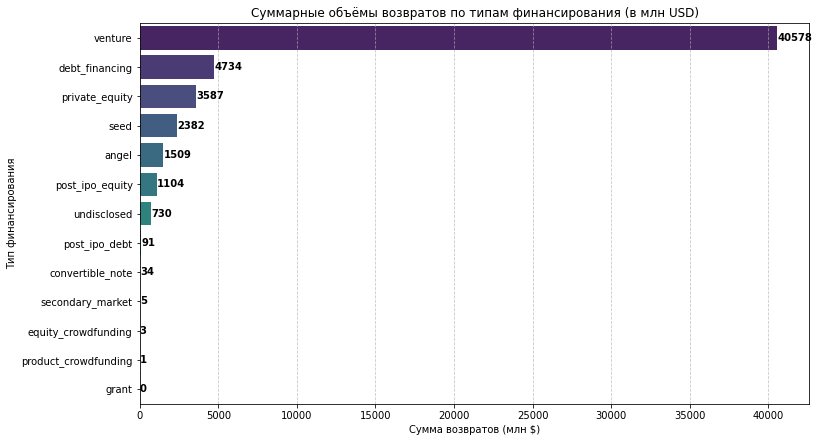

In [60]:
plt.figure(figsize=(12, 7))
ax = sns.barplot(x=total_returns.values, y=total_returns.index, palette='viridis')

for i, v in enumerate(total_returns.values):
    ax.text(v + 3, i, str(int(v)), color='black', va='center', fontweight='bold')
    
plt.title('Суммарные объёмы возвратов по типам финансирования (в млн USD)')
plt.xlabel('Сумма возвратов (млн $)')
plt.ylabel('Тип финансирования')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


Venture, опять же, лидирует (инвесторы могут выйграть большие суммы при венчурном финансировании).
Гранты же на графике равны 0, так как это безвозвратное финансирование. Находившийся в тройке лидеров и по объёму и по количеству предоставленных средств seed перешёл на четвёртое место по возвратам.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Рассчитаем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы построим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

На основе полученных данных ответим на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [61]:
df_final['avg_round_funding'] = df_final['funding_total_usd'] / df_final['funding_rounds']

/tmp/ipykernel_401/3968203057.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['avg_round_funding'] = df_final['funding_total_usd'] / df_final['funding_rounds']


In [62]:
result_table = df_final[['name', 'funding_total_usd', 'funding_rounds', 'avg_round_funding']]
result_table

,name,funding_total_usd,funding_rounds,avg_round_funding
1,university of new brunswick,2000000.0,1.0,2000000.00
2,dupont,9000000.0,1.0,9000000.00
3,university of michigan,7700000.0,3.0,2566666.75
4,case western reserve university,540000.0,1.0,540000.00
7,duke university,8700000.0,1.0,8700000.00
...,...,...,...,...
49430,grid4c,1500000.0,1.0,1500000.00
49433,riversilica,1500000.0,1.0,1500000.00
49434,southgobi resources,9000000.0,1.0,9000000.00
49435,digibyte,250000.0,1.0,250000.00


Ранее отфильтровали в датасете данные только о компаниях, получавших финансирование в годы, когда было зафиксировано 50 или более раундов финансирования, по показателю mid_funding_at. Теперь построим динамику среднего чека по этим годам (mid_funding_year)

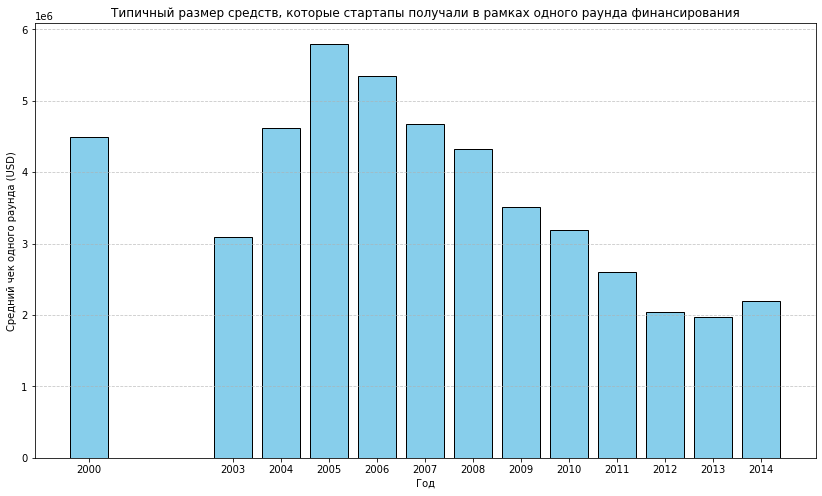

In [63]:
rounds_analysis = df_final.groupby('mid_funding_year')['avg_round_funding'].mean().reset_index()

plt.figure(figsize=(14, 8))
plt.bar(rounds_analysis['mid_funding_year'], rounds_analysis['avg_round_funding'], color='skyblue', edgecolor='black')

plt.title('Типичный размер средств, которые стартапы получали в рамках одного раунда финансирования')
plt.xlabel('Год')
plt.ylabel('Средний чек одного раунда (USD)')


plt.xticks(rounds_analysis['mid_funding_year']) 

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

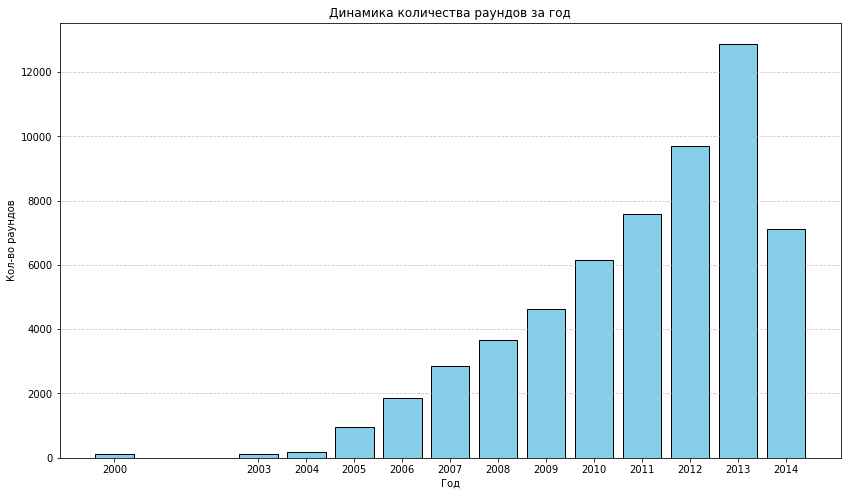

In [64]:
rounds_analysis = df_final.groupby('mid_funding_year')['funding_rounds'].sum().reset_index()

plt.figure(figsize=(14, 8))
plt.bar(rounds_analysis['mid_funding_year'], rounds_analysis['funding_rounds'], color='skyblue', edgecolor='black')

plt.title('Динамика количества раундов за год')
plt.xlabel('Год')
plt.ylabel('Кол-во раундов')

plt.xticks(rounds_analysis['mid_funding_year']) 

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Проанализируем эти два графика. Во первых, мы уже предположили ранее, что данные за 2014 год были неполными - на это можно списать резкое падение количества раундов за 2014 год. Среднее количество средств за раунд же подросло с 2013 года.
Сравнивая этот график с предыдущим (где падал средний чек одного раунда финансирования) получаем: В 2005 году было мало раундов (около 1000), но они были крупными (около 6 млн - максимальное значение средств, собранных в рамках одного раунда). К 2013 году раундов стало намного больше, но их средний размер упал до 2 млн.
Рынок стал меняться: перешел от крупного финансирования нескольких стартапов к небольшому финансированию многих. 
С 2005 года стартапы чаще получали меньшее финансирование на один раунд, но число сделок постоянно росло, отражая рост активности венчурного рынка.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в сегментах


In [65]:
pivot_funding = df_final.groupby(['mid_funding_year', 'market'])['funding_total_usd'].sum().unstack()
pivot_funding

market,advertising,analytics,apps,automotive,big data,biotechnology,clean technology,cloud computing,consulting,curated web,...,semiconductors,social media,social network media,software,sports,startups,technology,travel,video,web hosting
mid_funding_year,,,,,,,,,,,,,,,,,,,,,
2000.0,14470000.0,14822803.0,NaN,NaN,NaN,NaN,NaN,11500000.0,4500000.0,1000000.0,...,NaN,NaN,NaN,3.173264e+07,NaN,NaN,NaN,50230.0,NaN,95343088.0
2003.0,10500000.0,3840000.0,NaN,4530000.0,NaN,8.553118e+07,5.035294e+07,NaN,NaN,2550000.0,...,2.800000e+07,5000.0,NaN,6.608604e+07,NaN,NaN,NaN,NaN,5000000.0,NaN
2004.0,6000000.0,3000000.0,NaN,NaN,NaN,9.718486e+07,5.042795e+07,NaN,NaN,27050000.0,...,8.878280e+07,6850000.0,NaN,1.408238e+08,NaN,NaN,1750000.0,10230000.0,14704000.0,27000000.0
2005.0,127196024.0,79014048.0,NaN,22500000.0,NaN,4.800636e+08,1.942000e+07,NaN,44862000.0,53450000.0,...,5.862207e+08,14780000.0,5200000.0,9.930766e+08,1882200.0,NaN,50728424.0,27830000.0,6470551.0,483332640.0
2006.0,299299456.0,139701312.0,1310600.0,12660000.0,NaN,9.035005e+08,1.314739e+08,9951809.0,23965548.0,164673696.0,...,1.227941e+09,60169880.0,5245100.0,1.646869e+09,7000000.0,NaN,22791000.0,11700000.0,35171772.0,649959296.0
2007.0,556704320.0,98829000.0,NaN,37712600.0,7780000.0,1.704078e+09,7.497112e+08,20354344.0,70346344.0,314704512.0,...,1.616604e+09,89022512.0,24104020.0,1.686116e+09,16401580.0,NaN,180190208.0,13950000.0,85150640.0,361121440.0
2008.0,622673472.0,208077840.0,4300000.0,59478636.0,2452515.0,1.716033e+09,3.165808e+09,44375000.0,19061080.0,336500032.0,...,1.107199e+09,76034536.0,10998076.0,1.365006e+09,9554790.0,5010387.0,277726240.0,54905632.0,37865176.0,781623744.0
2009.0,563446016.0,140949328.0,7219000.0,20800312.0,597375.0,3.915900e+09,1.963503e+09,52223720.0,62715164.0,261360480.0,...,1.434207e+09,60033256.0,9451188.0,1.254334e+09,11808750.0,460700.0,36078848.0,24536468.0,22305584.0,471131040.0
2010.0,631617856.0,253739904.0,6123779.0,17696916.0,39233296.0,4.894500e+09,1.604429e+09,8525538.0,81264880.0,347018624.0,...,7.678236e+08,69447200.0,24043416.0,1.520172e+09,38184988.0,2111966.0,312526816.0,44461808.0,79974200.0,534480480.0


In [66]:
# сегменты, показавшие рост в 2014 по сравнению с 2013
growth_segments = pivot_funding.columns[pivot_funding.loc[2014] > pivot_funding.loc[2013]]
growth_segments

Index(['apps', 'big data', 'design', 'internet', 'manufacturing', 'medical',
       'mid', 'nan', 'niche', 'real estate', 'saas', 'startups', 'technology'],
      dtype='object', name='market')

In [67]:
# только растущие сегменты
df_growth = pivot_funding[growth_segments]

df_growth

market,apps,big data,design,internet,manufacturing,medical,mid,nan,niche,real estate,saas,startups,technology
mid_funding_year,,,,,,,,,,,,,
2000.0,NaN,NaN,NaN,10000000.0,56659312.0,24000000.0,8.244039e+07,1839560.0,14600000.0,2500000.0,NaN,NaN,NaN
2003.0,NaN,NaN,NaN,NaN,4269608.0,NaN,4.323840e+07,4155202.0,NaN,6292200.0,NaN,NaN,NaN
2004.0,NaN,NaN,NaN,10500000.0,3000000.0,NaN,5.443816e+07,10847977.0,NaN,NaN,NaN,NaN,1750000.0
2005.0,NaN,NaN,9300000.0,1775000.0,61770000.0,11090000.0,2.144075e+08,28384332.0,NaN,250000.0,5240000.0,NaN,50728424.0
2006.0,1310600.0,NaN,707000.0,5000.0,163957744.0,20250000.0,3.475226e+08,46049840.0,11180000.0,2080000.0,4791121.0,NaN,22791000.0
2007.0,NaN,7780000.0,10800000.0,4495379.0,147726048.0,2100000.0,5.035429e+08,35532468.0,44494636.0,33220000.0,14652595.0,NaN,180190208.0
2008.0,4300000.0,2452515.0,5944302.0,23412964.0,173054256.0,28812744.0,5.503748e+08,45345008.0,22279332.0,46613100.0,27226900.0,5010387.0,277726240.0
2009.0,7219000.0,597375.0,2150144.0,38195772.0,422862528.0,11566200.0,6.340655e+08,162033760.0,20754888.0,38840212.0,13536585.0,460700.0,36078848.0
2010.0,6123779.0,39233296.0,17239976.0,36657500.0,244329664.0,25590338.0,8.971823e+08,159085664.0,18659456.0,37344608.0,32609390.0,2111966.0,312526816.0


In [68]:
# не mid и не niche
growth_segments_mass = growth_segments[~growth_segments.isin(['mid', 'niche'])]
growth_segments_mass

Index(['apps', 'big data', 'design', 'internet', 'manufacturing', 'medical',
       'nan', 'real estate', 'saas', 'startups', 'technology'],
      dtype='object', name='market')

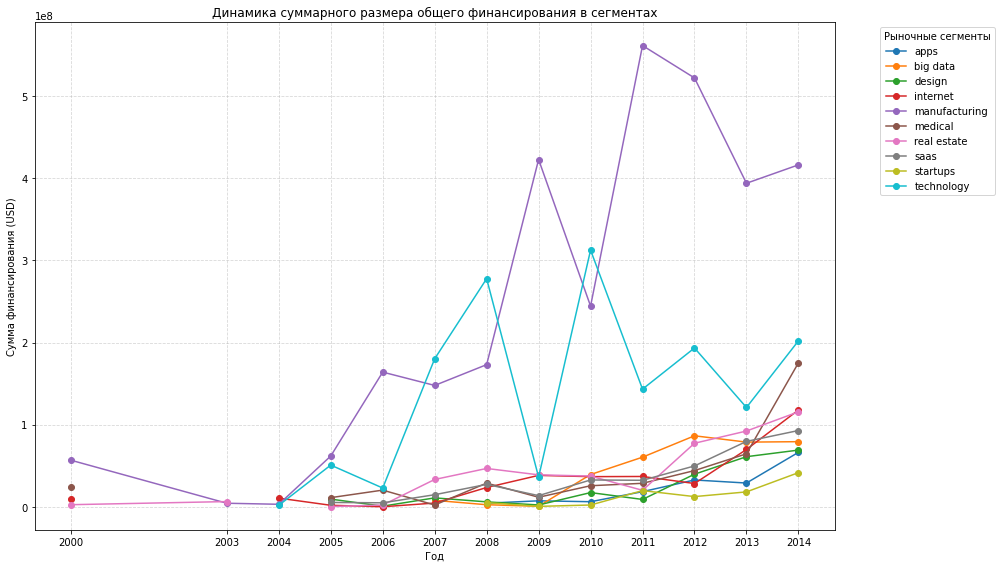

In [69]:
market_dynamics = (df_final[df_final['market'].isin(growth_segments_mass)& 
                        (df_final['market'] != 'nan')]
                   .groupby(['mid_funding_year', 'market'])['funding_total_usd']
                   .sum()
                   .unstack())

plt.figure(figsize=(14, 8))

for column in market_dynamics.columns:
    plt.plot(market_dynamics.index, market_dynamics[column], marker='o', label=column)

plt.title('Динамика суммарного размера общего финансирования в сегментах')
plt.xlabel('Год')
plt.ylabel('Сумма финансирования (USD)')

plt.xticks(market_dynamics.index) 
plt.legend(title='Рыночные сегменты', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Manufacturing, одно из самых высокофинансируемых направлений, демонстрирует скачки с пиками в 2009 и 2011 годах.
Technology характеризуется очень высокими колебаниями. Хотя в 2014 году виден рост, есть резкие провалы в 2009 и 2011 годах.

Medical, real estate показывают устойчивый рост, достигая к 2014 году одни из лидирующих значений в группе.

После 2010 года особенно сильно выросли инвестиции в сегменты manufacturing, тогда как остальные отрасли росли более умеренно и равномерно. Это указывает на смещение приоритетов инвесторов в сторону производства

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Цель: для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

In [70]:
funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
                 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

df_yearly = df_final.groupby('mid_funding_year').sum().reset_index()

In [71]:
df = pd.merge(df_yearly, df2, left_on='mid_funding_year', right_index=True, how='left')

In [72]:
for f_type in funding_types:
    invested = f_type + '_x' 
    returned = f_type + '_y' 
    
    df[f'{f_type}_norm'] = df[returned] * 1000000 / (df[invested]  + 1e-6)
    df.loc[df[f'{f_type}_norm'] > 5.0, f'{f_type}_norm'] = np.nan

df[['mid_funding_year'] + [f'{t}_norm' for t in funding_types]]

,mid_funding_year,seed_norm,venture_norm,equity_crowdfunding_norm,undisclosed_norm,convertible_note_norm,debt_financing_norm,angel_norm,grant_norm,private_equity_norm,post_ipo_equity_norm,post_ipo_debt_norm,secondary_market_norm,product_crowdfunding_norm
0,2000.0,0.996471,0.168922,0.000000,0.697042,0.000000,0.618571,0.266956,0.0,0.000000,0.271069,0.000000,0.025911,0.000000
1,2003.0,0.505276,0.628260,0.000000,0.914397,NaN,1.038095,0.605720,0.0,NaN,NaN,0.000000,NaN,0.000000
2,2004.0,0.548476,0.837009,0.000000,0.527559,NaN,0.439698,0.833504,0.0,NaN,NaN,0.000000,NaN,0.000000
3,2005.0,0.674695,0.546586,0.000000,1.071992,NaN,0.344964,0.509894,0.0,0.480000,0.731857,0.000000,NaN,0.000000
4,2006.0,0.925372,0.343678,0.203632,0.759438,0.166318,0.803772,0.674853,0.0,0.935453,NaN,0.000000,NaN,0.000000
5,2007.0,0.366153,0.297243,NaN,0.504971,0.228097,0.602488,0.817837,0.0,0.579056,2.030000,0.000000,NaN,0.000000
6,2008.0,0.297083,0.190873,NaN,0.342060,0.059788,0.927484,0.412476,0.0,0.679925,2.341111,0.000000,NaN,0.000000
7,2009.0,0.563423,0.169517,0.087819,0.376177,0.054535,0.388249,0.615945,0.0,0.789171,2.095613,0.000000,0.006218,0.065996
8,2010.0,0.526648,0.198810,0.052703,0.247851,0.067895,0.445147,0.639779,0.0,0.645955,1.353284,0.000000,0.197802,0.068571
9,2011.0,0.271989,0.256701,0.097035,0.229063,0.050373,0.500751,0.437522,0.0,0.731100,0.667069,0.980645,0.012800,0.014331


На графике отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделаем вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

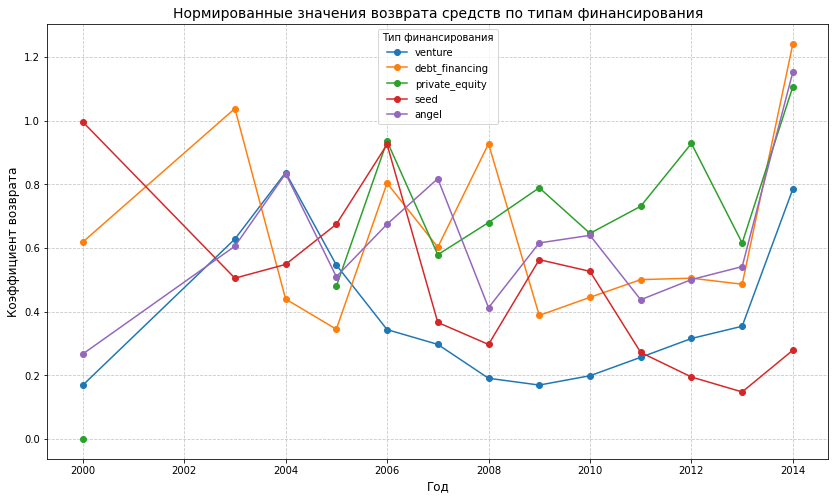

In [73]:
target_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
plot_cols = [f'{t}_norm' for t in target_types]

plt.figure(figsize=(14, 8))

for col in plot_cols:
    plt.plot(df['mid_funding_year'], df[col], marker='o', label=col.replace('_norm', ''))

plt.title('Нормированные значения возврата средств по типам финансирования', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Коэффициент возврата', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Тип финансирования')
plt.show()


Судя по полученному графику, мы можем провести анализ динамики роста коэффициента возврата для типов финансирования.
Наиболее устойчивый рост показателя наблюдается в типах Venture (самый стабильный тренд в конце периода).
Seed показывает отрицательную динамику. После 2006 года наблюдается стабильное снижение коэффициента возврата, что делает этот тип самым неустойчивым в плане роста.
Angel, Debt Financing показывают нестабильную динамику, но достигают высоких значений к концу периода.

## Шаг 5. Итоговый вывод и рекомендации

Представим, что на календаре 2015 год. Опираясь на результаты анализа, дадим рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.


**В какую отрасль инвестировать?**

Medical: оказывает стабильную динамику к 2014 году. Хотя самый популярный сегмент рынка - software - актуален, его популярность указывает на высокую конкуренцию в отрасли.

**Какой тип финансирования при этом будет наиболее уместным?**

Venture показывает наиболее устойчивый рост показателя коэффициента возврата, а также приемущество по объему возвратов.

В данном проекте были выполнены следующие шаги:
- загрузка и предобработка данных: обработка дубликатов и пропусков, проверка корректности числовых и временных значений.
- определение групп компаний по срокам финансирования, сравнение их по количеству и объёму инвестиций.
- классификация сегментов рынка на массовые, средние и нишевые и применение классификации в дальнейшем анализе.
- определение типичных и аномальных значений объёмов финансирования, исключение выбросов и ограничение периода исследования
- сравнение популярности и объёмов разных типов финансирования.
- анализ динамики раундов и объёмов инвестиций по годам, а также изменений в массовых сегментах рынка.
- расчет доли возврата средств для разных типов финансирования, оценка её устойчивости.
- подведение итога и приведение рекомендаций, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.

Были загружены датасеты cb_investments и cb_returns. Данные соответствовали описанию.

В результате предобработки данных были выполнены следующие действия:
- приведение названий столбцов к единому стилю
- оптимизация, нормализация типов данных
- удаление дубликатов и обработка пропусков

В процессе предобработки удалили дубликаты и строки, не несущие данные требуемой информации финансировании. Объем данных достаточен для предстоящего анализа.

Были сделаны следующие выводы:

- Компании с единичным финансированием составляют почти 59% от количества компаний. На втором месте по количеству - компании со сроком финансирования более года - 30%. Всего 11% - компании с финансированием менее года. Такое распределение можно объяснить низкой выживаемостью старт-апов.

- Более 60% капитала уходит на "проверенные" компании (более года), единичное финансирование - 30% (финансируется большОе количество проектов), всего 7.5% - до года.

- Самый популярный сегмент рынка - software. Сегменты с 120 и менее компаний были сгруппированы в две категории.

- Типичный интервал финансирования - от 350,000 до 10,000,000 USD. В real_estate и entertainment наибольшее количество экстремальных значений

- Venture - одновременно самый популярный тип финансирования, у него самый большой объем капитала, и общий объем возвратов. Анализ динамики роста коэффициента возврата для типов финансирования показывает, что наиболее устойчивый рост показателя наблюдается также у Venture (самый стабильный тренд в конце периода).

- Рассматривая динамику рынка, можно заметить, что он перешел от крупного финансирования нескольких стартапов к небольшому финансированию многих.

- Medical, real estate показывают устойчивый рост, достигая к 2014 году одни из лидирующих значений в группе.

Выводы преимущественно согласуются друг с другом, например, популярность Venture и его характеристики (то, что это самый стабильный и прибыльный тип, хорошо сочетается с тем, что рынок перешел к небольшому финансированию многих). Есть и противоречие: определили real estate как перспективную отрасль, но одновременно нашли большое количество экстремальных значений, что указывает на потенциально большой риск.

На этом анализ завершен, задачи выполнены.